# TOPIC for Causal Discovery in Topological Order

Demo of TOPIC,

1. how to simulate tabular data from a known nonlinear DAG,
2. how to run TOPIC on one dataset,
3. how to compare the learned graph to the true graph,
4. how to run the same graph search on multiple contexts with LINC.




In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from causalchange.causal_change import CausalChange
from causalchange.config.cc_types import (
    ContextAggregation,
    DataMode,
    GPType,
    GraphSearch,
)

## 1. Synthetic nonlinear data



In [3]:
true_edges = {
    ("x0", "x1"),
    ("x0", "x2"),
    ("x1", "x3"),
    ("x2", "x3"),
    ("x3", "x4"),
}


def standardize(df: pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean(axis=0)) / df.std(axis=0)


def simulate_topic_data(
    n: int = 800,
    seed: int = 42,
    noise_scale: float = 0.30,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    x0 = rng.normal(size=n)

    x1 = np.tanh(1.4 * x0) + rng.normal(scale=noise_scale, size=n)
    x2 = 0.6 * x0**2 + 0.3 * x0 + rng.normal(scale=noise_scale, size=n)
    x3 = np.sin(x1) + 0.7 * x2 + rng.normal(scale=noise_scale, size=n)
    x4 = np.tanh(x3) + rng.normal(scale=noise_scale, size=n)

    X = pd.DataFrame(
        {
            "x0": x0,
            "x1": x1,
            "x2": x2,
            "x3": x3,
            "x4": x4,
        }
    )

    return standardize(X)


X = simulate_topic_data()
X.head()

,x0,x1,x2,x3,x4
0,0.338838,0.226698,-0.469107,-0.254715,-0.334313
1,-1.027287,-1.534139,0.134625,-0.513059,0.032722
2,0.791674,1.172615,0.428309,1.057422,0.987499
3,0.984816,1.293777,-0.186324,0.475195,1.327328
4,-1.952852,-0.742148,1.160720,-0.079520,0.386492


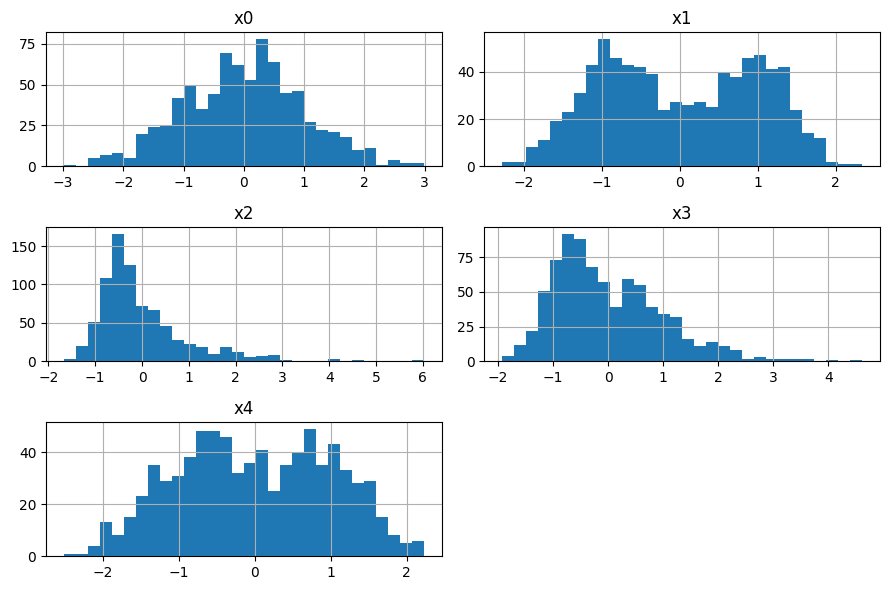

In [5]:
axes = X.hist(figsize=(9, 6), bins=30)
plt.tight_layout()
plt.show()

## 2. Run TOPIC


In [6]:
cc_topic = CausalChange(
    data_mode=DataMode.IID,
    graph_search=GraphSearch.TOPIC,
    score_type=GPType.FOURIER,
    aggregation=ContextAggregation.SKIP,
    score_kwargs={
        "D": 128,
        "restarts": 2,
        "refine": False,
        "seed": 42,
    },
)

cc_topic.fit(X)

print("Topological order:")
print(cc_topic.result_.topological_order)

print("\nEstimated edges:")
for edge in sorted(cc_topic.graph_.edges()):
    print("  ", edge)

Topological order:
['x0', 'x2', 'x1', 'x3', 'x4']

Estimated edges:
   ('x0', 'x1')
   ('x0', 'x2')
   ('x1', 'x3')
   ('x2', 'x3')
   ('x3', 'x4')


## 3. Eval



In [10]:
def edge_recovery_summary(estimated_edges, true_edges):
    estimated_edges = set(estimated_edges)
    true_edges = set(true_edges)

    tp = estimated_edges & true_edges
    fp = estimated_edges - true_edges
    fn = true_edges - estimated_edges

    precision = len(tp) / max(len(tp) + len(fp), 1)
    recall = len(tp) / max(len(tp) + len(fn), 1)

    return {
        "precision": precision,
        "recall": recall,
        "true_positives": sorted(tp),
        "false_positives": sorted(fp),
        "false_negatives": sorted(fn),
    }


summary = edge_recovery_summary(cc_topic.graph_.edges(), true_edges)
summary

{'precision': 1.0,
 'recall': 1.0,
 'true_positives': [('x0', 'x1'),
  ('x0', 'x2'),
  ('x1', 'x3'),
  ('x2', 'x3'),
  ('x3', 'x4')],
 'false_positives': [],
 'false_negatives': []}

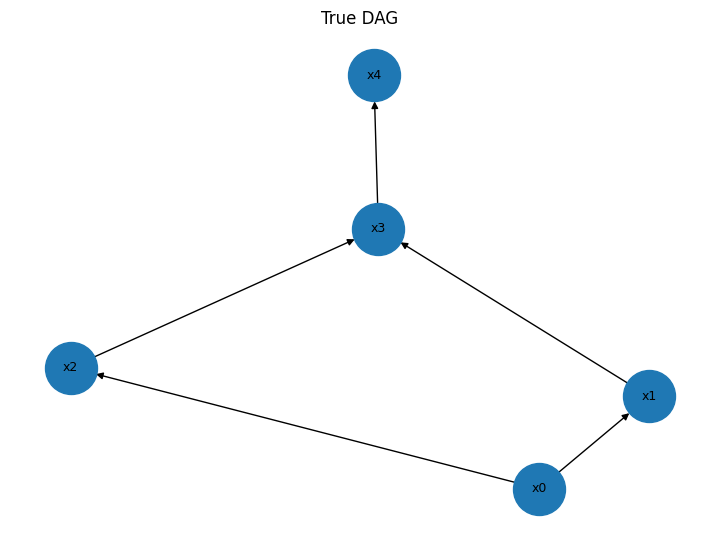

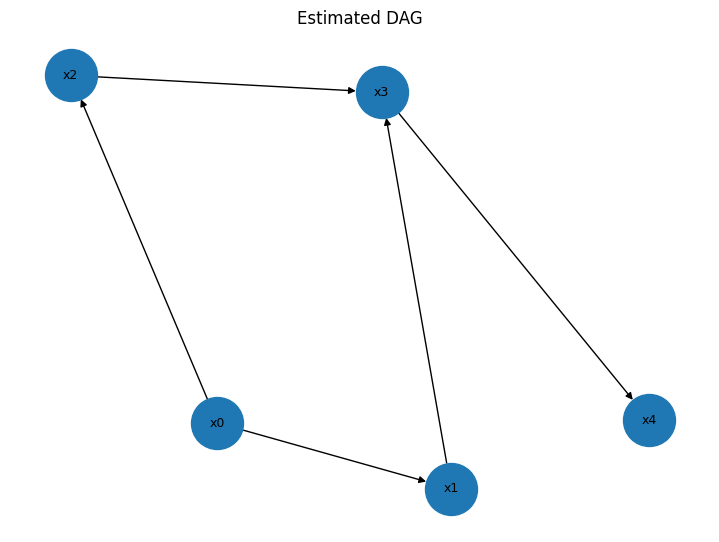

In [11]:
def plot_graph(graph, title=None):
    plt.figure(figsize=(7, 5))
    pos = nx.spring_layout(graph, seed=42)
    nx.draw(
        graph,
        pos=pos,
        with_labels=True,
        node_size=1400,
        font_size=9,
        arrows=True,
    )
    if title:
        plt.title(title)
    plt.show()


true_graph = nx.DiGraph()
true_graph.add_edges_from(true_edges)

plot_graph(true_graph, "True DAG")
plot_graph(cc_topic.graph_, "Estimated DAG")